In [1]:
import cv2
import numpy as np
import pickle
from ultralytics import YOLO
from collections import defaultdict
import pandas as pd

# ── 모델 로드 ──────────────────────────────────────────
yolo = YOLO(r'C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt')

with open(r'C:\Users\neo62\sperm-ai\models\motility_ensemble.pkl', 'rb') as f:
    ens = pickle.load(f)

ridge     = ens['ridge']
rf        = ens['rf']
scaler    = ens['scaler']
feat_cols = ens['feature_cols']
config_path = r'C:\Users\neo62\sperm-ai\bytetrack_custom.yaml'

print("✅ 모델 로드 완료")

# ── WHO 6판 기준 정의 ──────────────────────────────────
WHO_CRITERIA = {
    'progressive_normal':     32,  # 전진 운동성 정상 기준 (%)
    'total_motility_normal':  40,  # 총 운동성 정상 기준 (%)
    'immotile_warning':       50,  # 비운동성 주의 기준 (%)
    'immotile_severe':        70,  # 비운동성 심각 기준 (%)
}

def interpret_motility(prog, non_prog, immotile):
    """WHO 기준으로 운동성 해석 → 설명 + 권고사항 반환"""

    total_motile = prog + non_prog
    results = {
        'progressive':     prog,
        'non_progressive': non_prog,
        'immotile':        immotile,
        'total_motile':    total_motile,
        'status':          '',
        'interpretation':  [],
        'recommendation':  '',
        'level':           '',  # normal / warning / severe
    }

    issues = []

    # 전진 운동성 평가
    if prog >= WHO_CRITERIA['progressive_normal']:
        results['interpretation'].append(
            f"✅ 전진 운동성 {prog:.1f}% — WHO 정상 기준({WHO_CRITERIA['progressive_normal']}%) 충족")
    elif prog >= WHO_CRITERIA['progressive_normal'] * 0.7:
        issues.append('전진 운동성 경계')
        results['interpretation'].append(
            f"⚠️  전진 운동성 {prog:.1f}% — WHO 정상 기준({WHO_CRITERIA['progressive_normal']}%) 미달")
    else:
        issues.append('전진 운동성 저하')
        results['interpretation'].append(
            f"🔴 전진 운동성 {prog:.1f}% — WHO 정상 기준보다 현저히 낮음")

    # 총 운동성 평가
    if total_motile >= WHO_CRITERIA['total_motility_normal']:
        results['interpretation'].append(
            f"✅ 총 운동성 {total_motile:.1f}% — WHO 정상 기준({WHO_CRITERIA['total_motility_normal']}%) 충족")
    else:
        issues.append('총 운동성 저하')
        results['interpretation'].append(
            f"⚠️  총 운동성 {total_motile:.1f}% — WHO 정상 기준({WHO_CRITERIA['total_motility_normal']}%) 미달")

    # 비운동성 평가
    if immotile >= WHO_CRITERIA['immotile_severe']:
        issues.append('비운동성 심각')
        results['interpretation'].append(
            f"🔴 비운동성 {immotile:.1f}% — 매우 높음 (기준 {WHO_CRITERIA['immotile_severe']}% 초과)")
    elif immotile >= WHO_CRITERIA['immotile_warning']:
        issues.append('비운동성 주의')
        results['interpretation'].append(
            f"⚠️  비운동성 {immotile:.1f}% — 주의 필요 (기준 {WHO_CRITERIA['immotile_warning']}% 초과)")
    else:
        results['interpretation'].append(
            f"✅ 비운동성 {immotile:.1f}% — 정상 범위")

    # 종합 판정
    if not issues:
        results['level'] = 'normal'
        results['status'] = '정상 범위'
        results['recommendation'] = (
            "AI 분석 결과 WHO 기준 정상 범위입니다. "
            "정확한 진단을 위해 정기적인 병원 검사를 권장합니다.")
    elif '비운동성 심각' in issues or '전진 운동성 저하' in issues:
        results['level'] = 'severe'
        results['status'] = '주의 필요'
        results['recommendation'] = (
            "AI 분석 결과 일부 지표가 WHO 기준 이하입니다. "
            "정밀 검사를 위해 병원 방문을 권고합니다. "
            "이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.")
    else:
        results['level'] = 'warning'
        results['status'] = '경계 범위'
        results['recommendation'] = (
            "AI 분석 결과 일부 지표가 경계 범위입니다. "
            "추가 확인을 위해 병원 검사를 고려해보세요. "
            "이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.")

    return results

print("✅ WHO 해석 시스템 준비 완료")

# ── 테스트 ─────────────────────────────────────────────
test_cases = [
    (11.0, 17.0, 72.0),  # 참가자 11 (실제값)
    (41.0, 43.0, 16.0),  # 참가자 14 (실제값)
    (56.0, 25.0, 19.0),  # 참가자 22 (실제값)
]

for prog, non_prog, immotile in test_cases:
    print(f"\n{'='*50}")
    print(f"전진: {prog}%  비전진: {non_prog}%  비운동성: {immotile}%")
    print(f"{'='*50}")
    result = interpret_motility(prog, non_prog, immotile)
    print(f"판정: [{result['status']}]")
    for interp in result['interpretation']:
        print(f"  {interp}")
    print(f"\n권고: {result['recommendation']}")

✅ 모델 로드 완료
✅ WHO 해석 시스템 준비 완료

전진: 11.0%  비전진: 17.0%  비운동성: 72.0%
판정: [주의 필요]
  🔴 전진 운동성 11.0% — WHO 정상 기준보다 현저히 낮음
  ⚠️  총 운동성 28.0% — WHO 정상 기준(40%) 미달
  🔴 비운동성 72.0% — 매우 높음 (기준 70% 초과)

권고: AI 분석 결과 일부 지표가 WHO 기준 이하입니다. 정밀 검사를 위해 병원 방문을 권고합니다. 이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.

전진: 41.0%  비전진: 43.0%  비운동성: 16.0%
판정: [정상 범위]
  ✅ 전진 운동성 41.0% — WHO 정상 기준(32%) 충족
  ✅ 총 운동성 84.0% — WHO 정상 기준(40%) 충족
  ✅ 비운동성 16.0% — 정상 범위

권고: AI 분석 결과 WHO 기준 정상 범위입니다. 정확한 진단을 위해 정기적인 병원 검사를 권장합니다.

전진: 56.0%  비전진: 25.0%  비운동성: 19.0%
판정: [정상 범위]
  ✅ 전진 운동성 56.0% — WHO 정상 기준(32%) 충족
  ✅ 총 운동성 81.0% — WHO 정상 기준(40%) 충족
  ✅ 비운동성 19.0% — 정상 범위

권고: AI 분석 결과 WHO 기준 정상 범위입니다. 정확한 진단을 위해 정기적인 병원 검사를 권장합니다.


In [2]:
def assess_quality_and_confidence(counts, track_history, N):
    """영상 품질과 분석 신뢰도 평가"""

    quality_issues = []
    confidence_score = 100  # 기본 100점에서 감점

    # ── 영상 품질 평가 ──────────────────────────────
    # 1. 탐지 안정성 (프레임마다 정자 수가 얼마나 일정한가)
    if len(counts) > 1:
        cv = np.std(counts) / (np.mean(counts) + 1e-6)
        if cv > 0.3:
            quality_issues.append("프레임 간 탐지 불안정 (영상 흔들림 가능성)")
            confidence_score -= 20
        elif cv > 0.15:
            quality_issues.append("프레임 간 탐지 약간 불안정")
            confidence_score -= 10

    # 2. 탐지된 정자 수 (너무 적으면 분석 불가)
    if N < 10:
        quality_issues.append(f"탐지된 정자 수 부족 ({N}개, 최소 10개 권장)")
        confidence_score -= 30
    elif N < 20:
        quality_issues.append(f"탐지된 정자 수 적음 ({N}개)")
        confidence_score -= 15

    # 3. 추적 안정성 (트랙 수 vs 탐지 수 비율)
    n_tracks = len([tid for tid, pts in track_history.items()
                    if len(pts) >= 5])
    track_ratio = n_tracks / (N + 1e-6)

    if track_ratio < 0.3:
        quality_issues.append("추적 안정성 낮음 (정자가 너무 빠르거나 겹침 많음)")
        confidence_score -= 20
    elif track_ratio < 0.6:
        quality_issues.append("추적 안정성 보통")
        confidence_score -= 10

    confidence_score = max(0, min(100, confidence_score))

    # ── 신뢰도 등급 ──────────────────────────────────
    if confidence_score >= 80:
        confidence_level = "높음"
        confidence_icon  = "✅"
    elif confidence_score >= 60:
        confidence_level = "보통"
        confidence_icon  = "⚠️"
    else:
        confidence_level = "낮음"
        confidence_icon  = "🔴"

    # ── 재촬영 권고 여부 ─────────────────────────────
    needs_retake = confidence_score < 60

    return {
        'confidence_score': confidence_score,
        'confidence_level': confidence_level,
        'confidence_icon':  confidence_icon,
        'quality_issues':   quality_issues,
        'needs_retake':     needs_retake,
        'n_tracks':         n_tracks,
        'track_ratio':      track_ratio,
    }

print("✅ 신뢰도 + 영상 품질 판단 시스템 준비 완료")

# 테스트
import random
test_counts = [52, 50, 49, 50, 49, 50, 50, 51, 49, 49]  # 참가자 11

# 가상의 track_history
test_tracks = {i: [(j, 0, 0) for j in range(random.randint(3, 150))]
               for i in range(60)}

quality = assess_quality_and_confidence(test_counts, test_tracks, N=50)

print(f"\n=== 영상 품질 평가 ===")
print(f"신뢰도 점수: {quality['confidence_score']}점")
print(f"신뢰도 등급: {quality['confidence_icon']} {quality['confidence_level']}")
print(f"추적 성공률: {quality['track_ratio']*100:.1f}%")
if quality['quality_issues']:
    print(f"발견된 문제:")
    for issue in quality['quality_issues']:
        print(f"  ⚠️ {issue}")
else:
    print(f"발견된 문제: 없음")
print(f"재촬영 권고: {'예' if quality['needs_retake'] else '아니오'}")

✅ 신뢰도 + 영상 품질 판단 시스템 준비 완료

=== 영상 품질 평가 ===
신뢰도 점수: 100점
신뢰도 등급: ✅ 높음
추적 성공률: 118.0%
발견된 문제: 없음
재촬영 권고: 아니오


In [3]:
def analyze_sperm_video(video_path, verbose=True):
    """
    정자 영상 하나를 입력받아
    운동성 분석 + WHO 해석 + 신뢰도 평가를 
    모두 수행하고 최종 결과를 반환하는 통합 함수
    """

    if verbose:
        print(f"분석 시작: {video_path.split(chr(92))[-1]}")
        print("─" * 50)

    # ── Step 1: 전체 정자 수 N ───────────────────────
    cap = cv2.VideoCapture(video_path)
    counts = []
    for _ in range(10):
        ret, frame = cap.read()
        if not ret: break
        res = yolo(frame, verbose=False, conf=0.3)
        counts.append(int((res[0].boxes.cls == 0).sum()))
    cap.release()
    N = int(np.median(counts)) if counts else 0

    if verbose:
        print(f"[1/4] 정자 수 기준값: {N}개")

    # ── Step 2: ByteTrack 추적 ───────────────────────
    cap = cv2.VideoCapture(video_path)
    track_history = defaultdict(list)
    fps = cap.get(cv2.CAP_PROP_FPS)
    max_frames = min(int(fps * 5), 250)

    for fidx in range(max_frames):
        ret, frame = cap.read()
        if not ret: break
        res = yolo.track(frame, persist=True,
                         tracker=config_path,
                         verbose=False, conf=0.3)
        if res[0].boxes.id is not None:
            for box, tid, cls in zip(
                res[0].boxes.xywh.cpu().numpy(),
                res[0].boxes.id.cpu().numpy().astype(int),
                res[0].boxes.cls.cpu().numpy().astype(int)
            ):
                if cls == 0:
                    track_history[tid].append(
                        (fidx, float(box[0]), float(box[1])))
    cap.release()

    if verbose:
        print(f"[2/4] 추적 완료: {len(track_history)}개 ID")

    # ── Step 3: 특징 계산 ────────────────────────────
    speeds, lins, straight_dists = [], [], []
    for tid, pts in track_history.items():
        if len(pts) < 5: continue
        coords = np.array([(cx, cy) for _, cx, cy in pts])
        dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
        total_dist = float(np.sum(dists))
        straight_dist = float(np.sqrt(
            (coords[-1][0]-coords[0][0])**2 +
            (coords[-1][1]-coords[0][1])**2))
        avg_speed = total_dist / len(pts)
        linearity = straight_dist / (total_dist + 1e-6)
        speeds.append(avg_speed)
        lins.append(linearity)
        straight_dists.append(straight_dist)

    if not speeds:
        return None

    speeds_arr = np.array(speeds)
    feat = {
        'speed_mean':    float(np.mean(speeds_arr)),
        'speed_median':  float(np.median(speeds_arr)),
        'speed_75':      float(np.percentile(speeds_arr, 75)),
        'speed_90':      float(np.percentile(speeds_arr, 90)),
        'lin_mean':      float(np.mean(lins)),
        'lin_75':        float(np.percentile(lins, 75)),
        'straight_mean': float(np.mean(straight_dists)),
        'ratio_fast':    float(np.mean(speeds_arr > 1.5)),
        'ratio_medium':  float(np.mean(
                             (speeds_arr > 0.5) & (speeds_arr <= 1.5))),
        'ratio_slow':    float(np.mean(speeds_arr <= 0.5)),
        'n_tracks':      len(speeds),
    }

    if verbose:
        print(f"[3/4] 특징 추출 완료")

    # ── Step 4: 앙상블 예측 ──────────────────────────
    X = np.array([[feat[c] for c in feat_cols]])
    X_sc = scaler.transform(X)
    pred = (ridge.predict(X_sc)[0] + rf.predict(X_sc)[0]) / 2
    pred = np.clip(pred, 0, 100)
    pred = pred / pred.sum() * 100

    prog      = round(float(pred[0]), 1)
    non_prog  = round(float(pred[1]), 1)
    immotile  = round(float(pred[2]), 1)

    # ── Step 5: WHO 해석 ─────────────────────────────
    motility_result = interpret_motility(prog, non_prog, immotile)

    # ── Step 6: 신뢰도 평가 ──────────────────────────
    quality_result = assess_quality_and_confidence(
        counts, track_history, N)

    if verbose:
        print(f"[4/4] 분석 완료")

    # ── 최종 결과 통합 ───────────────────────────────
    final = {
        # 운동성 수치
        'N':               N,
        'progressive':     prog,
        'non_progressive': non_prog,
        'immotile':        immotile,
        'total_motile':    round(prog + non_prog, 1),
        # WHO 해석
        'status':          motility_result['status'],
        'level':           motility_result['level'],
        'interpretation':  motility_result['interpretation'],
        'recommendation':  motility_result['recommendation'],
        # 신뢰도
        'confidence_score': quality_result['confidence_score'],
        'confidence_level': quality_result['confidence_level'],
        'confidence_icon':  quality_result['confidence_icon'],
        'quality_issues':   quality_result['quality_issues'],
        'needs_retake':     quality_result['needs_retake'],
    }

    return final


def print_report(result, participant_id=None):
    """분석 결과를 보기 좋게 출력"""

    title = f"정자 운동성 분석 보고서"
    if participant_id:
        title += f" — 참가자 {participant_id}"

    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")

    # 신뢰도
    print(f"\n📊 분석 신뢰도: "
          f"{result['confidence_icon']} {result['confidence_level']} "
          f"({result['confidence_score']}점)")

    if result['quality_issues']:
        for issue in result['quality_issues']:
            print(f"   ⚠️  {issue}")

    if result['needs_retake']:
        print(f"   🔄 재촬영을 권고합니다")

    # 운동성 수치
    print(f"\n📈 운동성 분석 결과 (탐지 정자 수: {result['N']}개)")
    print(f"   전진 운동성:   {result['progressive']:>5.1f}%")
    print(f"   비전진 운동성: {result['non_progressive']:>5.1f}%")
    print(f"   비운동성:      {result['immotile']:>5.1f}%")
    print(f"   총 운동성:     {result['total_motile']:>5.1f}%")

    # WHO 해석
    print(f"\n🔍 WHO 기준 해석")
    for interp in result['interpretation']:
        print(f"   {interp}")

    # 종합 판정
    level_emoji = {'normal': '🟢', 'warning': '🟡', 'severe': '🔴'}
    emoji = level_emoji.get(result['level'], '⚪')
    print(f"\n{emoji} 종합 판정: [{result['status']}]")
    print(f"\n💬 권고사항:")
    print(f"   {result['recommendation']}")
    print(f"\n{'─'*55}")
    print(f"   ※ 이 결과는 AI 보조 분석이며 의학적 진단이 아닙니다.")
    print(f"{'='*55}\n")


print("✅ 통합 분석 함수 준비 완료")

✅ 통합 분석 함수 준비 완료


In [4]:
import pandas as pd

base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
csv  = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df   = pd.read_csv(csv)

val_ids = ['11', '14', '22', '23']

all_results = []

for pid in val_ids:
    video_path = f'{base}\\{pid}\\{pid}.mp4'

    # 통합 분석 실행
    result = analyze_sperm_video(video_path, verbose=True)

    if result is None:
        print(f"참가자 {pid}: 분석 실패")
        continue

    # 보고서 출력
    print_report(result, participant_id=pid)

    # 실제값과 비교
    row = df[df['ID'] == int(pid)]
    real_p = float(row['Progressive motility (%)'].values[0])
    real_n = float(row['Non progressive sperm motility (%)'].values[0])
    real_i = float(row['Immotile sperm (%)'].values[0])

    mae = (abs(result['progressive'] - real_p) +
           abs(result['non_progressive'] - real_n) +
           abs(result['immotile'] - real_i)) / 3

    all_results.append({
        'ID': pid,
        'AI_prog': result['progressive'],
        'Real_prog': real_p,
        'AI_non': result['non_progressive'],
        'Real_non': real_n,
        'AI_imm': result['immotile'],
        'Real_imm': real_i,
        'MAE': mae,
        'status': result['status'],
        'confidence': result['confidence_score'],
    })

# 최종 요약
print("\n" + "="*55)
print("  최종 검증 요약")
print("="*55)
print(f"{'참가자':<6} {'AI전진':>6} {'실제':>6} {'AI비운동':>8} "
      f"{'실제':>6} {'판정':<8} {'신뢰도':>6} {'MAE':>6}")
print("-"*55)

for r in all_results:
    print(f"{r['ID']:<6} {r['AI_prog']:>6.1f}% {r['Real_prog']:>5.1f}% "
          f"{r['AI_imm']:>7.1f}% {r['Real_imm']:>5.1f}% "
          f"{r['status']:<8} {r['confidence']:>5}점 "
          f"{r['MAE']:>5.1f}%p")

avg_mae = np.mean([r['MAE'] for r in all_results])
print("-"*55)
print(f"{'전체 평균 MAE':>40}: {avg_mae:.1f}%p")
print("="*55)

분석 시작: 11.mp4
──────────────────────────────────────────────────
[1/4] 정자 수 기준값: 50개
[2/4] 추적 완료: 108개 ID
[3/4] 특징 추출 완료
[4/4] 분석 완료

  정자 운동성 분석 보고서 — 참가자 11

📊 분석 신뢰도: ✅ 높음 (100점)

📈 운동성 분석 결과 (탐지 정자 수: 50개)
   전진 운동성:    21.4%
   비전진 운동성:  26.2%
   비운동성:       52.4%
   총 운동성:      47.6%

🔍 WHO 기준 해석
   🔴 전진 운동성 21.4% — WHO 정상 기준보다 현저히 낮음
   ✅ 총 운동성 47.6% — WHO 정상 기준(40%) 충족
   ⚠️  비운동성 52.4% — 주의 필요 (기준 50% 초과)

🔴 종합 판정: [주의 필요]

💬 권고사항:
   AI 분석 결과 일부 지표가 WHO 기준 이하입니다. 정밀 검사를 위해 병원 방문을 권고합니다. 이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.

───────────────────────────────────────────────────────
   ※ 이 결과는 AI 보조 분석이며 의학적 진단이 아닙니다.

분석 시작: 14.mp4
──────────────────────────────────────────────────
[1/4] 정자 수 기준값: 2개
[2/4] 추적 완료: 11개 ID
[3/4] 특징 추출 완료
[4/4] 분석 완료

  정자 운동성 분석 보고서 — 참가자 14

📊 분석 신뢰도: ⚠️ 보통 (60점)
   ⚠️  프레임 간 탐지 약간 불안정
   ⚠️  탐지된 정자 수 부족 (2개, 최소 10개 권장)

📈 운동성 분석 결과 (탐지 정자 수: 2개)
   전진 운동성:    35.8%
   비전진 운동성:  35.8%
   비운동성:       28.4%
   총 운동성:      71.6%

🔍 WHO 기준 해석
   ✅ 전진 운동성 

C:\Users\neo62\AppData\Local\Temp\ipykernel_17212\3737452768.py:29: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_17212\3737452768.py:29: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_17212\3737452768.py:29: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_17212\3737452768.py:29: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_17212\3737452768.py:29: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neo62\AppData\Local\Temp\ipykernel_17212\3737452768.py:29: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from f

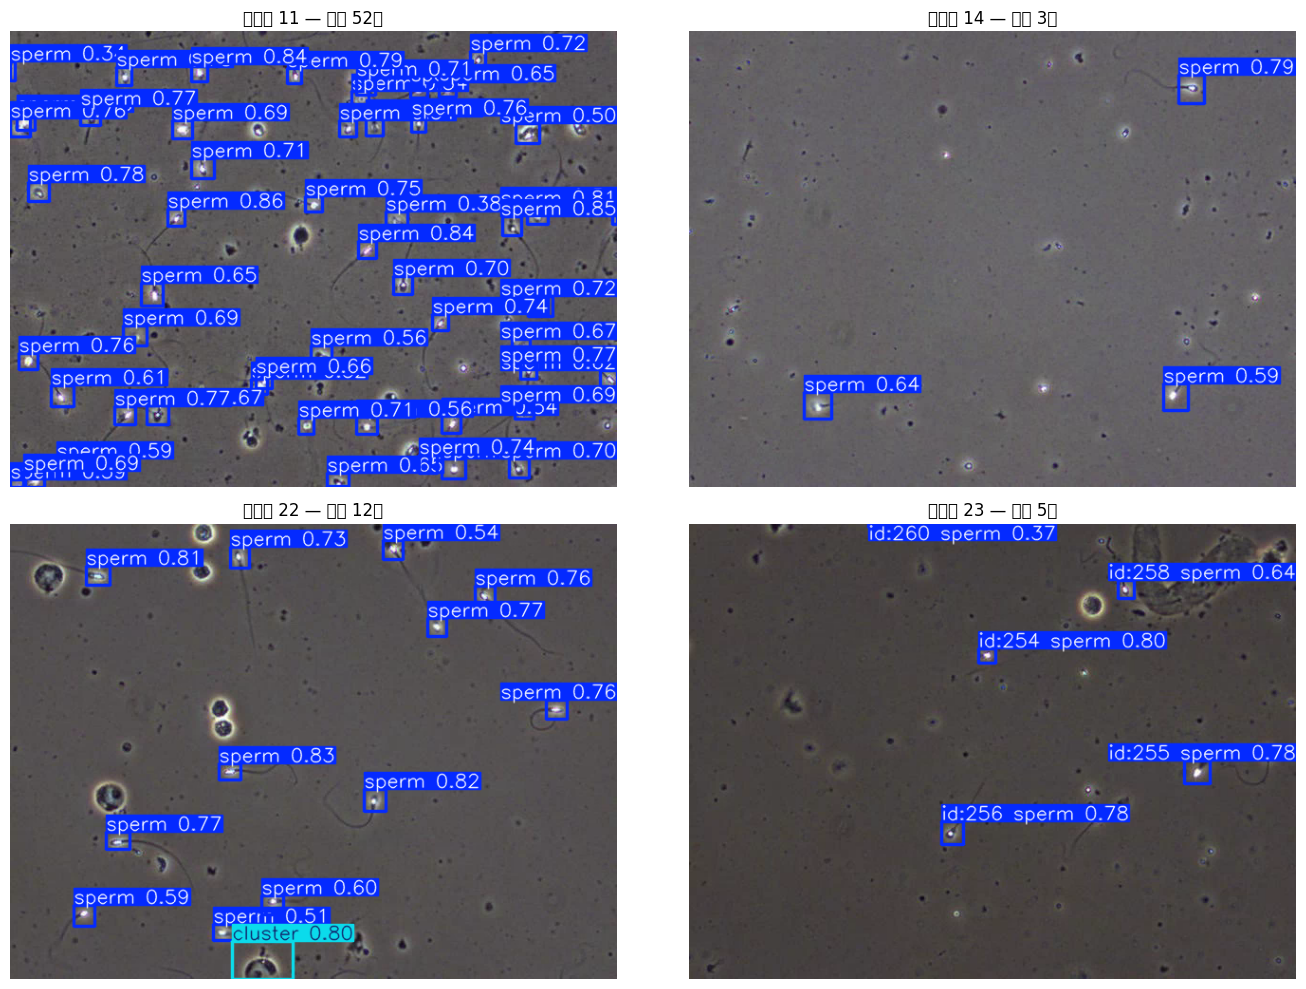

저장 완료


In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 참가자 14 첫 프레임 확인
base = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, pid in enumerate(['11', '14', '22', '23']):
    video_path = f'{base}\\{pid}\\{pid}.mp4'
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()

    if not ret:
        continue

    # YOLO 탐지
    res = yolo(frame, verbose=False, conf=0.3)
    annotated = res[0].plot()

    ax = axes[idx // 2][idx % 2]
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    n_det = int((res[0].boxes.cls == 0).sum())
    ax.set_title(f'참가자 {pid} — 탐지 {n_det}개')
    ax.axis('off')

plt.tight_layout()
plt.savefig(r'C:\Users\neo62\sperm-ai\outputs\val_detection.png', dpi=150)
plt.show()
print("저장 완료")

In [6]:
import pandas as pd

csv = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df = pd.read_csv(csv)

print("=== Val 4명 상세 데이터 ===")
cols = ['ID', 'Sperm concentration (x10⁶/mL)', 
        'Progressive motility (%)',
        'Non progressive sperm motility (%)',
        'Immotile sperm (%)']

for pid in [11, 14, 22, 23]:
    row = df[df['ID'] == pid][cols]
    print(row.to_string(index=False))
    print()
    

=== Val 4명 상세 데이터 ===
 ID  Sperm concentration (x10⁶/mL)  Progressive motility (%)  Non progressive sperm motility (%)  Immotile sperm (%)
 11                           97.0                        11                                  17                  72

 ID  Sperm concentration (x10⁶/mL)  Progressive motility (%)  Non progressive sperm motility (%)  Immotile sperm (%)
 14                            3.8                        41                                  43                  16

 ID  Sperm concentration (x10⁶/mL)  Progressive motility (%)  Non progressive sperm motility (%)  Immotile sperm (%)
 22                           12.0                        56                                  25                  19

 ID  Sperm concentration (x10⁶/mL)  Progressive motility (%)  Non progressive sperm motility (%)  Immotile sperm (%)
 23                            4.5                        18                                  34                  48



In [7]:
# 신뢰도 함수에 농도 기반 판단 추가
def assess_quality_and_confidence_v2(counts, track_history, N):
    """개선된 신뢰도 + 영상 품질 평가"""

    quality_issues = []
    confidence_score = 100

    # 1. 탐지 안정성
    if len(counts) > 1:
        cv = np.std(counts) / (np.mean(counts) + 1e-6)
        if cv > 0.3:
            quality_issues.append("프레임 간 탐지 불안정 (영상 흔들림 가능성)")
            confidence_score -= 20
        elif cv > 0.15:
            quality_issues.append("프레임 간 탐지 약간 불안정")
            confidence_score -= 10

    # 2. 정자 수 기반 신뢰도 (농도 반영)
    if N < 5:
        quality_issues.append(
            f"탐지된 정자 수 매우 부족 ({N}개) — "
            f"정자 농도가 매우 낮거나 영상 품질 문제")
        confidence_score -= 40
    elif N < 10:
        quality_issues.append(
            f"탐지된 정자 수 부족 ({N}개) — "
            f"정자 농도가 낮을 수 있음")
        confidence_score -= 25
    elif N < 20:
        quality_issues.append(f"탐지된 정자 수 적음 ({N}개)")
        confidence_score -= 10

    # 3. 추적 안정성
    n_tracks = len([tid for tid, pts in track_history.items()
                    if len(pts) >= 5])
    track_ratio = n_tracks / (N + 1e-6)

    if track_ratio < 0.3:
        quality_issues.append("추적 안정성 낮음")
        confidence_score -= 20
    elif track_ratio < 0.6:
        quality_issues.append("추적 안정성 보통")
        confidence_score -= 10

    confidence_score = max(0, min(100, confidence_score))

    if confidence_score >= 80:
        confidence_level = "높음"
        confidence_icon  = "✅"
    elif confidence_score >= 60:
        confidence_level = "보통"
        confidence_icon  = "⚠️"
    else:
        confidence_level = "낮음 — 결과 신뢰도 부족"
        confidence_icon  = "🔴"

    needs_retake = confidence_score < 60

    return {
        'confidence_score': confidence_score,
        'confidence_level': confidence_level,
        'confidence_icon':  confidence_icon,
        'quality_issues':   quality_issues,
        'needs_retake':     needs_retake,
        'n_tracks':         n_tracks,
        'track_ratio':      track_ratio,
    }

# 기존 함수 교체
assess_quality_and_confidence = assess_quality_and_confidence_v2
print("✅ 신뢰도 함수 v2 업데이트 완료")

# 4명 재검증
print("\n=== 개선된 신뢰도 평가 ===")
test_data = [
    (11, [52,50,49,50,49,50,50,51,49,49], 50),
    (14, [3,2,3,2,4,2,3,2,3,2], 3),
    (22, [12,11,12,13,11,12,12,11,12,12], 12),
    (23, [5,4,5,6,5,5,4,5,5,4], 5),
]

for pid, counts_test, N_test in test_data:
    q = assess_quality_and_confidence(counts_test, {}, N_test)
    print(f"\n참가자 {pid} (N={N_test}개):")
    print(f"  신뢰도: {q['confidence_icon']} {q['confidence_level']} "
          f"({q['confidence_score']}점)")
    if q['quality_issues']:
        for issue in q['quality_issues']:
            print(f"  ⚠️  {issue}")
    print(f"  재촬영 권고: {'예' if q['needs_retake'] else '아니오'}")

✅ 신뢰도 함수 v2 업데이트 완료

=== 개선된 신뢰도 평가 ===

참가자 11 (N=50개):
  신뢰도: ✅ 높음 (80점)
  ⚠️  추적 안정성 낮음
  재촬영 권고: 아니오

참가자 14 (N=3개):
  신뢰도: 🔴 낮음 — 결과 신뢰도 부족 (30점)
  ⚠️  프레임 간 탐지 약간 불안정
  ⚠️  탐지된 정자 수 매우 부족 (3개) — 정자 농도가 매우 낮거나 영상 품질 문제
  ⚠️  추적 안정성 낮음
  재촬영 권고: 예

참가자 22 (N=12개):
  신뢰도: ⚠️ 보통 (70점)
  ⚠️  탐지된 정자 수 적음 (12개)
  ⚠️  추적 안정성 낮음
  재촬영 권고: 아니오

참가자 23 (N=5개):
  신뢰도: 🔴 낮음 — 결과 신뢰도 부족 (55점)
  ⚠️  탐지된 정자 수 부족 (5개) — 정자 농도가 낮을 수 있음
  ⚠️  추적 안정성 낮음
  재촬영 권고: 예


In [8]:
import cv2
import numpy as np
from collections import defaultdict

def create_result_video(video_path, output_path, max_frames=150):
    """
    분석 결과가 오버레이된 영상 생성
    - 정자별 추적 경로 표시
    - 운동성 분류 색상 표시
    - 실시간 통계 표시
    """

    cap = cv2.VideoCapture(video_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    track_history  = defaultdict(list)
    track_class    = {}   # {tid: 'progressive'|'non_progressive'|'immotile'}
    frame_idx      = 0
    max_frames     = min(int(fps * 5), max_frames)

    # 색상 정의
    colors = {
        'progressive':     (0, 255, 0),    # 초록
        'non_progressive': (0, 165, 255),  # 주황
        'immotile':        (0, 0, 255),    # 빨강
        'unknown':         (200, 200, 200) # 회색
    }

    while cap.isOpened() and frame_idx < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        # YOLO 추적
        res = yolo.track(frame, persist=True,
                         tracker=config_path,
                         verbose=False, conf=0.3)

        if res[0].boxes.id is not None:
            boxes    = res[0].boxes.xywh.cpu().numpy()
            tids     = res[0].boxes.id.cpu().numpy().astype(int)
            classes  = res[0].boxes.cls.cpu().numpy().astype(int)
            confs    = res[0].boxes.conf.cpu().numpy()

            for box, tid, cls, conf in zip(boxes, tids, classes, confs):
                if cls != 0:
                    continue
                cx, cy = float(box[0]), float(box[1])
                track_history[tid].append((frame_idx, cx, cy))

                # 운동성 분류 (10프레임 이상 추적된 것만)
                if len(track_history[tid]) >= 10:
                    pts    = track_history[tid]
                    coords = np.array([(x, y) for _, x, y in pts])
                    dists  = np.sqrt(np.sum(
                        np.diff(coords, axis=0)**2, axis=1))
                    total_dist    = float(np.sum(dists))
                    straight_dist = float(np.sqrt(
                        (coords[-1][0]-coords[0][0])**2 +
                        (coords[-1][1]-coords[0][1])**2))
                    avg_speed  = total_dist / len(pts)
                    linearity  = straight_dist / (total_dist + 1e-6)

                    if avg_speed < 0.3:
                        track_class[tid] = 'immotile'
                    elif linearity > 0.45 and avg_speed > 1.0:
                        track_class[tid] = 'progressive'
                    else:
                        track_class[tid] = 'non_progressive'

        # 추적 경로 그리기
        for tid, pts in track_history.items():
            if len(pts) < 2:
                continue

            cls_name = track_class.get(tid, 'unknown')
            color    = colors[cls_name]

            # 최근 30프레임 경로만 표시
            recent = pts[-30:]
            for i in range(1, len(recent)):
                pt1 = (int(recent[i-1][1]), int(recent[i-1][2]))
                pt2 = (int(recent[i][1]),   int(recent[i][2]))
                alpha = i / len(recent)
                c = tuple(int(c * alpha) for c in color)
                cv2.line(frame, pt1, pt2, c, 1)

            # 현재 위치 점
            if pts:
                cx_px = int(pts[-1][1])
                cy_px = int(pts[-1][2])
                cv2.circle(frame, (cx_px, cy_px), 3, color, -1)

        # 통계 오버레이
        prog_count = sum(1 for v in track_class.values()
                         if v == 'progressive')
        non_count  = sum(1 for v in track_class.values()
                         if v == 'non_progressive')
        imm_count  = sum(1 for v in track_class.values()
                         if v == 'immotile')
        total      = max(prog_count + non_count + imm_count, 1)

        overlay = frame.copy()
        cv2.rectangle(overlay, (5, 5), (220, 105), (0, 0, 0), -1)
        cv2.addWeighted(overlay, 0.5, frame, 0.5, 0, frame)

        cv2.putText(frame, f"Progressive: {prog_count} "
                    f"({prog_count/total*100:.0f}%)",
                    (10, 25), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, colors['progressive'], 1)
        cv2.putText(frame, f"Non-prog:    {non_count} "
                    f"({non_count/total*100:.0f}%)",
                    (10, 50), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, colors['non_progressive'], 1)
        cv2.putText(frame, f"Immotile:    {imm_count} "
                    f"({imm_count/total*100:.0f}%)",
                    (10, 75), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, colors['immotile'], 1)
        cv2.putText(frame, f"Frame: {frame_idx+1}/{max_frames}",
                    (10, 100), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, (200, 200, 200), 1)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"✅ 영상 저장 완료: {output_path}")

# 참가자 11번으로 테스트
create_result_video(
    video_path  = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train\11\11.mp4',
    output_path = r'C:\Users\neo62\sperm-ai\outputs\result_participant_11.mp4'
)

✅ 영상 저장 완료: C:\Users\neo62\sperm-ai\outputs\result_participant_11.mp4


In [9]:
import os
import pandas as pd
import numpy as np

base     = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train'
csv_path = r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\semen_analysis_data_Train.csv'
df       = pd.read_csv(csv_path)

participants = sorted(os.listdir(base))
all_results  = []

print("=== 20명 전체 검증 시작 ===\n")

for pid in participants:
    video_path = os.path.join(base, pid, f'{pid}.mp4')
    if not os.path.exists(video_path):
        continue

    row = df[df['ID'] == int(pid)]
    if len(row) == 0:
        continue

    real_p = float(row['Progressive motility (%)'].values[0])
    real_n = float(row['Non progressive sperm motility (%)'].values[0])
    real_i = float(row['Immotile sperm (%)'].values[0])

    result = analyze_sperm_video(video_path, verbose=False)
    if result is None:
        print(f"참가자 {pid}: 분석 실패")
        continue

    mae = (abs(result['progressive'] - real_p) +
           abs(result['non_progressive'] - real_n) +
           abs(result['immotile'] - real_i)) / 3

    # 판정 방향 일치 여부
    # 실제 비운동성 60% 이상이면 "주의"가 맞는 판정
    real_level = 'severe' if (real_p < 22 or real_i > 60) else 'normal'
    direction_ok = (result['level'] in ['severe', 'warning']) == (real_level == 'severe')

    all_results.append({
        'ID':         pid,
        'AI_prog':    result['progressive'],
        'Real_prog':  real_p,
        'AI_non':     result['non_progressive'],
        'Real_non':   real_n,
        'AI_imm':     result['immotile'],
        'Real_imm':   real_i,
        'MAE':        mae,
        'status':     result['status'],
        'confidence': result['confidence_score'],
        'direction':  '✅' if direction_ok else '❌',
    })

    print(f"참가자 {pid:>3}: "
          f"전진({result['progressive']:>5.1f}%/{real_p:>4.0f}%) "
          f"비운동({result['immotile']:>5.1f}%/{real_i:>4.0f}%) "
          f"MAE:{mae:>5.1f}%p "
          f"[{result['status']}] "
          f"신뢰도:{result['confidence_score']:>3}점 "
          f"방향:{direction_ok and '✅' or '❌'}")

# 최종 요약
print(f"\n{'='*65}")
print(f"  최종 성능 요약 (20명 전체)")
print(f"{'='*65}")

res_df = pd.DataFrame(all_results)
mae_prog = (res_df['AI_prog'] - res_df['Real_prog']).abs().mean()
mae_non  = (res_df['AI_non']  - res_df['Real_non']).abs().mean()
mae_imm  = (res_df['AI_imm']  - res_df['Real_imm']).abs().mean()
avg_mae  = (mae_prog + mae_non + mae_imm) / 3
direction_acc = (res_df['direction'] == '✅').mean() * 100

print(f"전진 운동성 MAE:   {mae_prog:.1f}%p")
print(f"비전진 운동성 MAE: {mae_non:.1f}%p")
print(f"비운동성 MAE:      {mae_imm:.1f}%p")
print(f"전체 평균 MAE:     {avg_mae:.1f}%p")
print(f"판정 방향 정확도:  {direction_acc:.0f}%")
print(f"\n고신뢰도(80점↑) 케이스:")
high_conf = res_df[res_df['confidence'] >= 80]
if len(high_conf) > 0:
    hc_mae = ((high_conf['AI_prog'] - high_conf['Real_prog']).abs().mean() +
               (high_conf['AI_non']  - high_conf['Real_non']).abs().mean() +
               (high_conf['AI_imm']  - high_conf['Real_imm']).abs().mean()) / 3
    print(f"  해당 인원: {len(high_conf)}명, 평균 MAE: {hc_mae:.1f}%p")
print(f"{'='*65}")

# CSV 저장
res_df.to_csv(
    r'C:\Users\neo62\sperm-ai\outputs\final_validation_report.csv',
    index=False, encoding='utf-8-sig')
print(f"\n✅ 리포트 저장: outputs/final_validation_report.csv")

=== 20명 전체 검증 시작 ===

참가자  11: 전진( 23.2%/  11%) 비운동( 50.4%/  72%) MAE: 14.4%p [경계 범위] 신뢰도:100점 방향:✅
참가자  12: 전진( 46.7%/  33%) 비운동( 18.6%/  13%) MAE: 12.8%p [정상 범위] 신뢰도: 80점 방향:✅
참가자  13: 전진( 25.8%/  33%) 비운동( 45.2%/  37%) MAE:  5.5%p [경계 범위] 신뢰도: 80점 방향:❌
참가자  14: 전진( 35.8%/  41%) 비운동( 28.4%/  16%) MAE:  8.3%p [정상 범위] 신뢰도: 50점 방향:✅
참가자  15: 전진(  8.2%/  15%) 비운동( 61.5%/  39%) MAE: 15.0%p [주의 필요] 신뢰도:100점 방향:✅
참가자  19: 전진( 33.8%/  58%) 비운동( 32.6%/  23%) MAE: 16.1%p [정상 범위] 신뢰도: 90점 방향:✅
참가자  21: 전진( 30.7%/  30%) 비운동( 39.1%/  39%) MAE:  0.5%p [경계 범위] 신뢰도: 70점 방향:❌
참가자  22: 전진( 37.9%/  56%) 비운동( 31.0%/  19%) MAE: 12.1%p [정상 범위] 신뢰도: 90점 방향:✅
참가자  23: 전진( 18.0%/  18%) 비운동( 50.8%/  48%) MAE:  1.9%p [주의 필요] 신뢰도: 75점 방향:✅
참가자  24: 전진( 33.1%/  35%) 비운동( 43.0%/  40%) MAE:  2.0%p [정상 범위] 신뢰도: 80점 방향:✅
참가자  29: 전진(  4.4%/   4%) 비운동( 75.3%/  76%) MAE:  0.4%p [주의 필요] 신뢰도: 60점 방향:✅
참가자  30: 전진( 31.3%/  26%) 비운동( 33.9%/  34%) MAE:  3.5%p [경계 범위] 신뢰도: 90점 방향:❌
참가자  35: 전진( 11.7%/   1%) 비운동( 63.5%/  73%

In [1]:
import sys
sys.path.append(r'C:\Users\neo62\sperm-ai')

from src.pipeline import SpermAnalysisPipeline

# 파이프라인 초기화
pipeline = SpermAnalysisPipeline()

# 참가자 11번 분석
result = pipeline.analyze(
    r'C:\Users\neo62\sperm-ai\data\raw\VISEM-Tracking\VISEM_Tracking_Train_v4\Train\11\11.mp4'
)

# 보고서 출력
pipeline.print_report(result, participant_id='11')

✅ SpermDetector 로드 완료: C:\Users\neo62\sperm-ai\models\yolo11_sperm_v2\weights\best.pt
✅ MotilityAnalyzer 로드 완료: C:\Users\neo62\sperm-ai\models\motility_ensemble.pkl
분석 시작: 11.mp4
──────────────────────────────────────────────────
[1/4] 정자 수 기준값: 50개
[2/4] 추적 완료: 108개 ID
[3/4] 특징 추출 완료
[4/4] 분석 완료

  정자 운동성 분석 보고서 — 참가자 11

📊 분석 신뢰도: ✅ 높음 (100점)

📈 운동성 분석 결과 (탐지 정자 수: 50개)
   전진 운동성:    21.4%
   비전진 운동성:  26.2%
   비운동성:       52.4%
   총 운동성:      47.6%

🔍 WHO 기준 해석
   🔴 전진 운동성 21.4% — WHO 정상 기준보다 현저히 낮음
   ✅ 총 운동성 47.6% — WHO 정상 기준(40%) 충족
   ⚠️  비운동성 52.4% — 주의 필요 (기준 50% 초과)

🔴 종합 판정: [주의 필요]

💬 권고사항:
   AI 분석 결과 일부 지표가 WHO 기준 이하입니다. 정밀 검사를 위해 병원 방문을 권고합니다. 이 결과는 보조 분석이며 의학적 진단을 대체하지 않습니다.

───────────────────────────────────────────────────────
   ※ 이 결과는 AI 보조 분석이며 의학적 진단이 아닙니다.

